In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys
import os

# Replace 'YOUR_PROJECT_DIRECTORY_IN_DRIVE' with the actual path to your project folder in Google Drive
project_path = '/content/drive/MyDrive/attention-project'

# Add the project path to the system path
if project_path not in sys.path:
    sys.path.append(project_path)

# Verify that the path has been added (optional)
print(f"Current Python path: {sys.path}")

# You might also want to change the current working directory if your project expects it
# os.chdir(project_path)


Current Python path: ['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/drive/MyDrive/attention-project']


After running the above cells, please verify that the output of `Current Python path:` includes your project directory. Then, you can retry running the import cell.

In [3]:
import torch

from models.model import AttentionCNN

from utils.dataset import get_dataloaders
from utils.evaluate import evaluate_model
from utils.visualize import visualize

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using:", device)

Using: cuda


In [5]:
train_loader, test_loader = get_dataloaders()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [6]:
model = AttentionCNN().to(device)

In [8]:
model_path = "/content/drive/MyDrive/attention-project/weights/best_model.pth"

model.load_state_dict(
    torch.load(
        model_path,
        map_location=device
    )
)

model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [9]:
evaluate_model(
    model,
    test_loader,
    model_path
)


Overall Test Accuracy: 83.57%

Per-Class Accuracy:
------------------------------
airplane    : 86.70%
automobile  : 92.90%
bird        : 75.50%
cat         : 68.70%
deer        : 83.20%
dog         : 76.20%
frog        : 88.60%
horse       : 82.60%
ship        : 91.40%
truck       : 89.90%


83.57

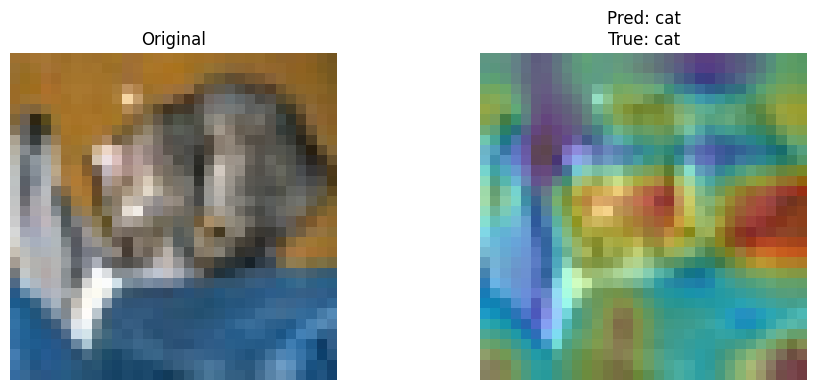

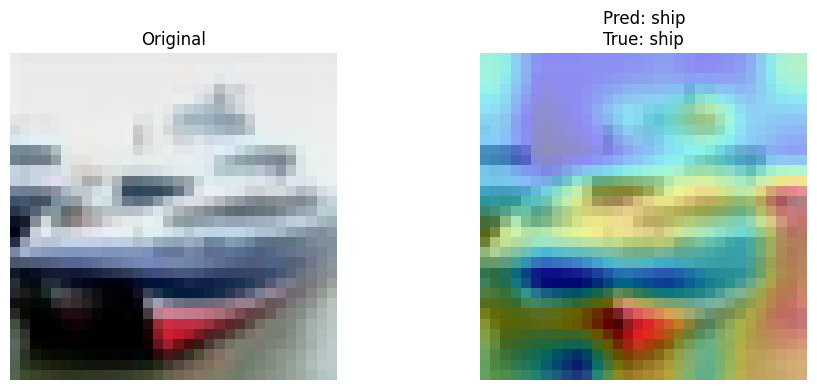

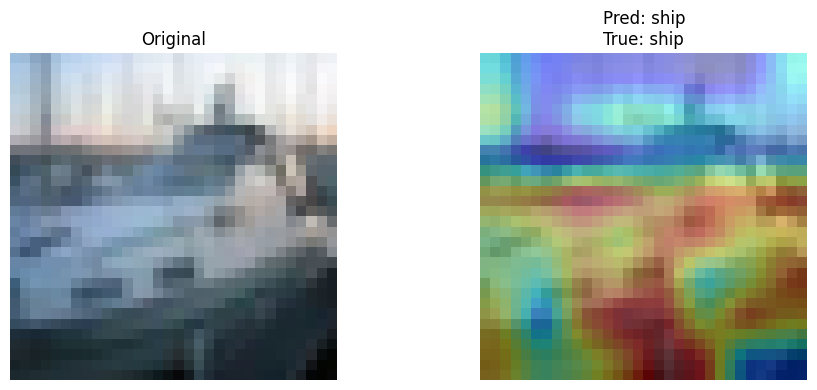

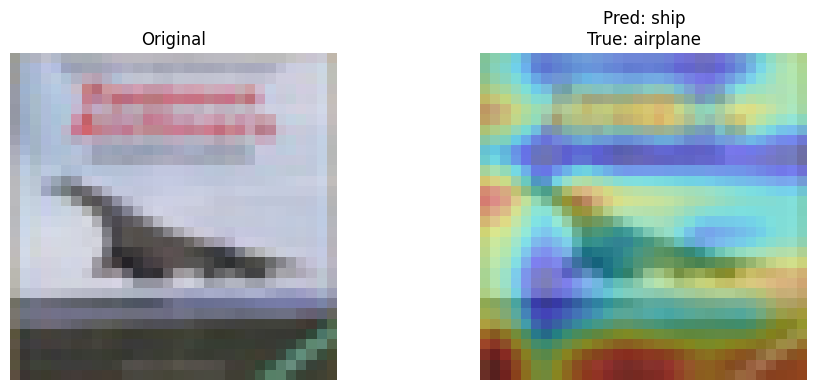

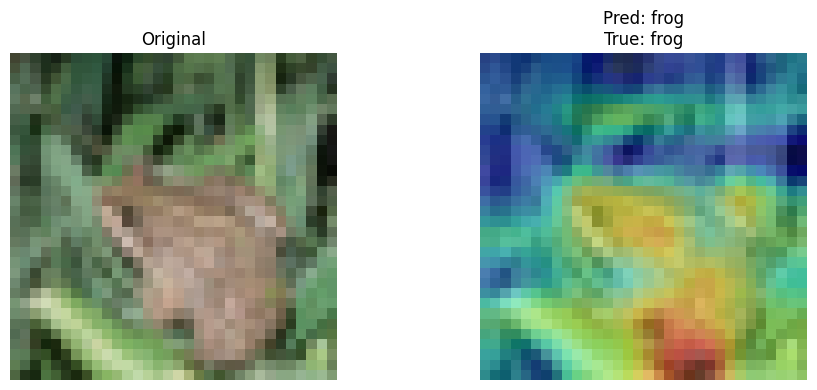

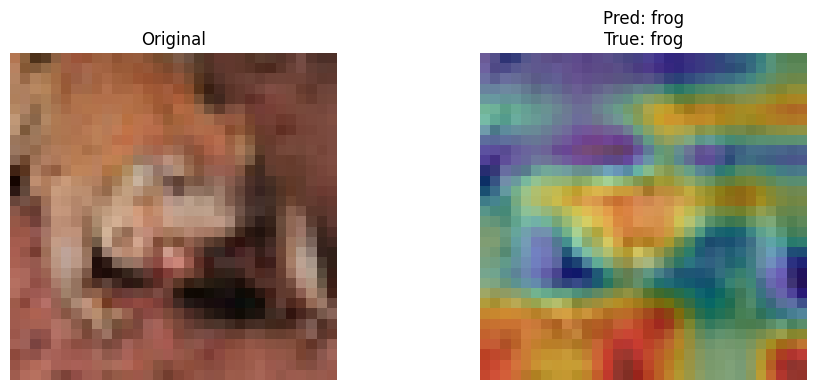

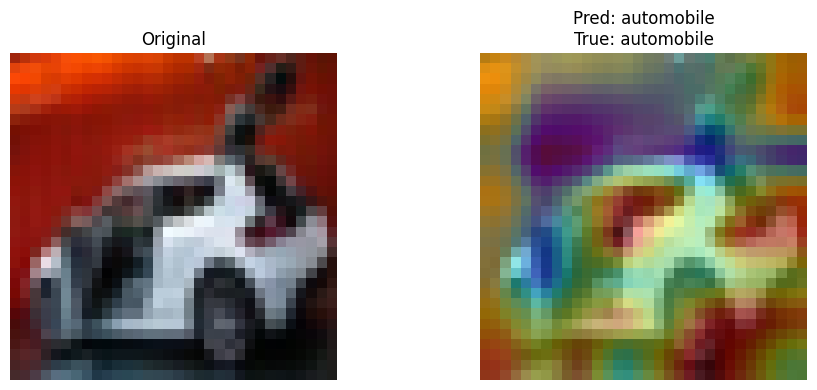

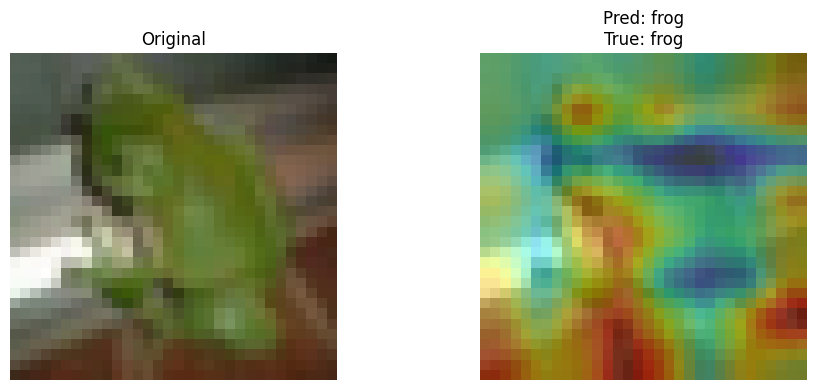

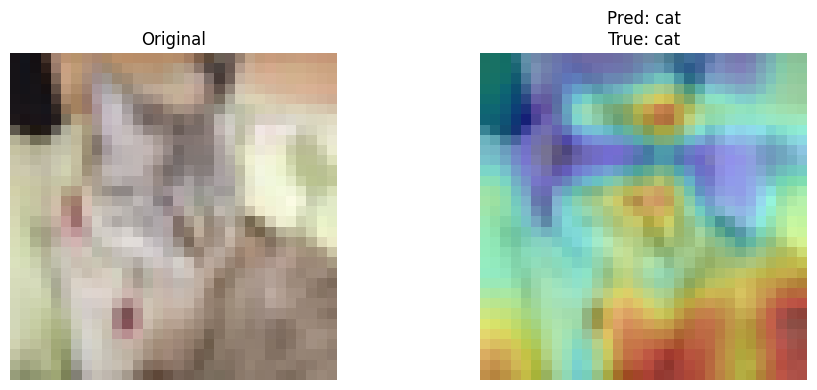

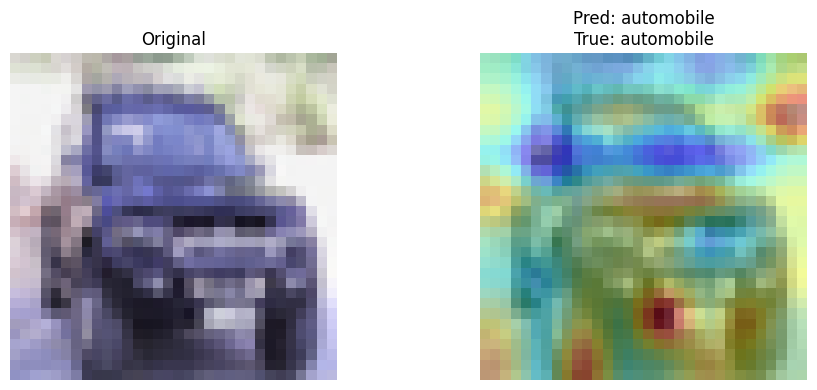

In [11]:
visualize(
    model,
    test_loader,
    num_images=10
)